In [1]:
# Activate the local LorenzParameterEstimation package
import Pkg
Pkg.activate("../../")  # Activate the main project environment
Pkg.instantiate()  # Ensure all dependencies are installed

using PlotlyJS
using Random
using LinearAlgebra
using Statistics
using Enzyme

using DataFrames

using SparseArrays
using LorenzParameterEstimation

# Set random seed for reproducibility
Random.seed!(42)

  Activating project at `~/master_thesis/LorenzParameterEstimation`


TaskLocalRNG()

# Visualisations

In [2]:
# ===============================================================
#  Stationary Continuity Solver for the Lorenz System
#  Implements Algorithm 1 from “Optimal Transport for Parameter Identification”
#  Steps 1–6: Discretization → Flux assembly → Markovization → Teleportation → Power iteration
# ===============================================================

function lorenz_pdf_grid_safe(p::L63Parameters{T};
    nx::Int=64, ny::Int=64, nz::Int=48,
    domain=(-30.0, 30.0, -30.0, 30.0, 0.0, 60.0),
    ε::T=T(1e-3),                      # teleportation regularization
    c::Union{Nothing,T}=nothing,       # Markov scaling factor
    maxiter::Int=10_000, tol::T=T(1e-12)
) where {T<:Real}

    # ===========================================================
    # (1) GRID DISCRETIZATION AND INDEXING
    # -----------------------------------------------------------
    # Define a uniform finite-volume grid in x,y,z and precompute
    # cell centers and spacings. Each grid cell will carry one
    # unknown: the probability density ρ[i,j,k].
    # ===========================================================

    domT = T.(domain)
    xL, xR, yL, yR, zL, zR = domT

    hx = (xR - xL) / T(nx)
    hy = (yR - yL) / T(ny)
    hz = (zR - zL) / T(nz)

    xs = collect(range(xL + hx / T(2), xR - hx / T(2); length=nx))
    ys = collect(range(yL + hy / T(2), yR - hy / T(2); length=ny))
    zs = collect(range(zL + hz / T(2), zR - hz / T(2); length=nz))

    n = nx * ny * nz                                # total number of cells
    @inline lin(i, j, k) = i + nx * (j - 1) + nx * ny * (k - 1)  # 3D→1D index

    # ===========================================================
    # (2) EVALUATE VELOCITY FIELD ON CELL FACES
    # -----------------------------------------------------------
    # For finite-volume flux computation we need the velocity
    # components on the faces of each cell. We use a staggered
    # layout (vx: x-faces, vy: y-faces, vz: z-faces).
    # ===========================================================

    vx = zeros(T, nx + 1, ny, nz)   # x-face velocities
    vy = zeros(T, nx, ny + 1, nz)   # y-face velocities
    vz = zeros(T, nx, ny, nz + 1)   # z-face velocities

    # --- fill vx on interior x-faces ---
    @inbounds for k in 1:nz, j in 1:ny, i in 2:nx
        xc = xL + hx * T(i - 1)
        vel = lorenz_rhs((xc, ys[j], zs[k]), p)
        vx[i, j, k] = vel[1]
    end

    # --- fill vy on interior y-faces ---
    @inbounds for k in 1:nz, j in 2:ny, i in 1:nx
        yc = yL + hy * T(j - 1)
        vel = lorenz_rhs((xs[i], yc, zs[k]), p)
        vy[i, j, k] = vel[2]
    end

    # --- fill vz on interior z-faces ---
    @inbounds for k in 2:nz, j in 1:ny, i in 1:nx
        zc = zL + hz * T(k - 1)
        vel = lorenz_rhs((xs[i], ys[j], zc), p)
        vz[i, j, k] = vel[3]
    end

    # ===========================================================
    # (3) BUILD THE FINITE-VOLUME OPERATOR R (advection flux matrix)
    # -----------------------------------------------------------
    # R encodes probability fluxes between neighboring cells
    # following an upwind scheme:
    # - off-diagonals = nonnegative inflow rates from upwind cells
    # - diagonal = negative sum of outgoing fluxes
    # Columns of R sum to zero → mass conservation.
    # ===========================================================

    invhx, invhy, invhz = inv(hx), inv(hy), inv(hz)
    rows = Int[]; cols = Int[]; vals = T[]
    max_out = zero(T)

    @inbounds for k in 1:nz, j in 1:ny, i in 1:nx
        col = lin(i, j, k)
        r_out = zero(T)

        # --- X-direction fluxes ---
        if i < nx
            rxR = max(vx[i + 1, j, k], zero(T)) * invhx
            if rxR > 0
                push!(rows, lin(i + 1, j, k)); push!(cols, col); push!(vals, rxR)
                r_out += rxR
            end
        end
        if i > 1
            rxL = max(-vx[i, j, k], zero(T)) * invhx
            if rxL > 0
                push!(rows, lin(i - 1, j, k)); push!(cols, col); push!(vals, rxL)
                r_out += rxL
            end
        end

        # --- Y-direction fluxes ---
        if j < ny
            ryU = max(vy[i, j + 1, k], zero(T)) * invhy
            if ryU > 0
                push!(rows, lin(i, j + 1, k)); push!(cols, col); push!(vals, ryU)
                r_out += ryU
            end
        end
        if j > 1
            ryD = max(-vy[i, j, k], zero(T)) * invhy
            if ryD > 0
                push!(rows, lin(i, j - 1, k)); push!(cols, col); push!(vals, ryD)
                r_out += ryD
            end
        end

        # --- Z-direction fluxes ---
        if k < nz
            rzT = max(vz[i, j, k + 1], zero(T)) * invhz
            if rzT > 0
                push!(rows, lin(i, j, k + 1)); push!(cols, col); push!(vals, rzT)
                r_out += rzT
            end
        end
        if k > 1
            rzB = max(-vz[i, j, k], zero(T)) * invhz
            if rzB > 0
                push!(rows, lin(i, j, k - 1)); push!(cols, col); push!(vals, rzB)
                r_out += rzB
            end
        end

        # --- Diagonal entry (mass leaving the current cell) ---
        max_out = max(max_out, r_out)
        if r_out > 0
            push!(rows, col); push!(cols, col); push!(vals, -r_out)
        end
    end

    # Assemble sparse matrix R (generator of the Markov process)
    R = SparseArrays.sparse(rows, cols, vals, n, n)

    # ===========================================================
    # (4) FORM MARKOV OPERATOR P = I + cR
    # -----------------------------------------------------------
    # Choose scaling c so that all entries of P are nonnegative
    # (stochastic columns). This makes P a discrete Perron–
    # Frobenius operator whose invariant vector is the stationary PDF.
    # ===========================================================

    if c === nothing
        c = max_out > 0 ? T(0.95) / max_out : T(1)
    end
    P = LinearAlgebra.I + c .* R

    # ===========================================================
    # (5) ADD TELEPORTATION REGULARIZATION (PageRank trick)
    # -----------------------------------------------------------
    # Prevents reducibility and ensures uniqueness of ρ:
    # Pε = (1−ε)P + ε*(1/n)*11ᵀ
    # Implemented by mixing each iteration with the uniform density.
    # ===========================================================

    one_n = T(1) / T(n)
    ρ = fill(one_n, n)     # initial uniform distribution
    tmp = similar(ρ)

    # ===========================================================
    # (6) POWER ITERATION TO FIND THE STATIONARY DENSITY
    # -----------------------------------------------------------
    # Iterate ρ_{k+1} = Pερ_k until convergence (‖Δρ‖₁ < tol)
    # This converges to the unique positive stationary solution
    # of the discrete stationary continuity equation.
    # ===========================================================

    for it in 1:maxiter
        # propagate one step
        LinearAlgebra.mul!(tmp, P, ρ)

        # teleportation mix: tmp ← (1−ε)*tmp + ε*(uniform)
        @inbounds @simd for q in eachindex(tmp)
            tmp[q] = (1 - ε) * tmp[q] + ε * one_n
        end

        # normalization (keep total mass = 1)
        s = sum(tmp)
        isfinite(s) || error("Encountered non-finite iterate at it=$it; try larger ε or finer grid.")
        tmp ./= s

        # convergence check (L1 norm)
        if LinearAlgebra.norm(tmp .- ρ, 1) < tol
            ρ .= tmp
            break
        end

        # swap buffers for next iteration
        ρ, tmp = tmp, ρ
    end

    # ensure nonnegative and normalized density
    ρ .= max.(ρ, zero(T))
    ρ ./= sum(ρ)

    # ===========================================================
    # RETURN RESULTS
    # -----------------------------------------------------------
    # xs, ys, zs : cell center coordinates
    # reshape(ρ) : invariant PDF on the 3D grid
    # ===========================================================

    return xs, ys, zs, reshape(ρ, nx, ny, nz)
end

lorenz_pdf_grid_safe (generic function with 1 method)

In [3]:
base_params = classic_params()
# Initial condition 
u0 = [1.0, 1.0, 1.0]
M  = 20_000
T  = 100.0
dt = T / M

# Integrate both systems
sol_basic  = integrate(base_params, u0, (0.0, T), dt)

# Extract coordinates (solution has time along rows, variables along columns)
x = sol_basic.u[:, 1]
y = sol_basic.u[:, 2]
z = sol_basic.u[:, 3]

# Create interactive Plotly 3D line
trace = PlotlyJS.scatter3d(x = x, y = y, z = z, mode = "lines",
                  line = attr(color = "blue", width = 1))

layout = Layout(
    title = "Classic Lorenz (ρ=28.0)",
    scene = attr(
        xaxis = attr(title = "X"),
        yaxis = attr(title = "Y"),
        zaxis = attr(title = "Z")
    ),
    width = 1200,
    height = 400
)

PlotlyJS.plot([trace], layout)

InterruptException: InterruptException:

In [ ]:
# Plane views: XY, XZ, YZ in a single row of subplots
trace_xy = PlotlyJS.scatter(x = x, y = y, mode = "lines",
    line = attr(color = "blue", width = 1), name = "X vs Y")

trace_xz = PlotlyJS.scatter(x = x, y = z, mode = "lines",
    line = attr(color = "red", width = 1), xaxis = "x2", yaxis = "y2", name = "X vs Z")

trace_yz = PlotlyJS.scatter(x = y, y = z, mode = "lines",
    line = attr(color = "green", width = 1), xaxis = "x3", yaxis = "y3", name = "Y vs Z")

layout = Layout(
    title = "Lorenz Plane Views",
    width = 1200,
    height = 400,
    xaxis  = attr(domain = [0.00, 0.32], title = "X"),
    yaxis  = attr(domain = [0.00, 1.00], title = "Y"),
    xaxis2 = attr(domain = [0.34, 0.66], title = "X"),
    yaxis2 = attr(domain = [0.00, 1.00], title = "Z"),
    xaxis3 = attr(domain = [0.68, 1.00], title = "Y"),
    yaxis3 = attr(domain = [0.00, 1.00], title = "Z"),
    showlegend = false
)

PlotlyJS.plot([trace_xy, trace_xz, trace_yz], layout)

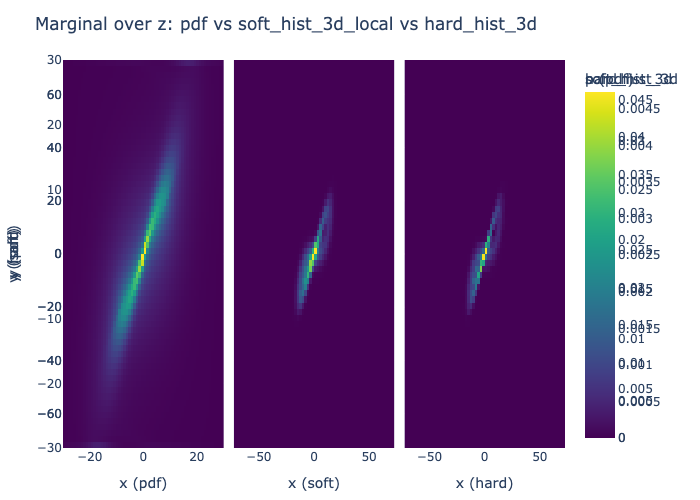

In [4]:
# compute marginals and plot comparison: pdf (lorenz_pdf_grid_safe), soft_hist_3d_local, hard_hist_3d
xs, ys, zs, rho_pdf = lorenz_pdf_grid_safe(base_params; nx=64, ny=64, nz=48)
z_pdf = dropdims(sum(rho_pdf, dims=3), dims=3)'  # transpose for heatmap (x->cols, y->rows)

# build soft (kernel) histogram from sol_basic and hard (bin) histogram over same centers
nbins = 64  # 64 is heavy; 16–32 is fine to start
xs_traj = sol_basic.u[:,1]; ys_traj = sol_basic.u[:,2]; zs_traj = sol_basic.u[:,3]
hw = maximum(abs, vcat(xs_traj, ys_traj, zs_traj)) * 1.50

pdf_cfg = make_pdf_config(Float64; nbins=nbins, range_halfwidth=hw, loss_mode=:kl)
centers = pdf_cfg.centers
Δ = (centers[end] - centers[1]) / (length(centers) - 1)
h = 0.5 * Δ
pdf_cfg = make_pdf_config(Float64; nbins=nbins, range_halfwidth=hw, loss_mode=:kl, bandwidth=h)

# soft (kernel) histogram
p3d_soft = zeros(Float64, nbins^3)
R = max(1, ceil(Int, 3h/Δ))
soft_hist_3d_local(xs_traj, ys_traj, zs_traj, centers, h, p3d_soft; R=R)
p3d_soft ./= sum(p3d_soft)
rho_soft = reshape(p3d_soft, nbins, nbins, nbins)

# hard (bin) histogram using the @inline signature: hard_hist_3d(xs, ys, zs, centers, out)
p3d_hard = zeros(Float64, nbins^3)
hard_hist_3d(xs_traj, ys_traj, zs_traj, centers, p3d_hard)
p3d_hard ./= sum(p3d_hard)
rho_hard = reshape(p3d_hard, nbins, nbins, nbins)

# marginals over z (transpose for heatmap orientation)
z_soft = dropdims(sum(rho_soft, dims=3), dims=3)'
z_hard = dropdims(sum(rho_hard, dims=3), dims=3)'

# traces: pdf uses xs,ys from lorenz_pdf_grid_safe; soft/hard use centers
trace_pdf  = PlotlyJS.heatmap(x=xs, y=ys, z=z_pdf,  colorscale="Viridis",
    colorbar=attr(title="ρ (pdf)"), name="pdf")

trace_soft = PlotlyJS.heatmap(x=centers, y=centers, z=z_soft, colorscale="Viridis",
    colorbar=attr(title="soft_hist_3d"), xaxis="x2", yaxis="y2", name="soft")

trace_hard = PlotlyJS.heatmap(x=centers, y=centers, z=z_hard, colorscale="Viridis",
    colorbar=attr(title="hard_hist_3d"), xaxis="x3", yaxis="y3", name="hard")

layout = Layout(
    title = "Marginal over z: pdf vs soft_hist_3d_local vs hard_hist_3d",
    width = 1200,
    height = 420,
    xaxis  = attr(domain = [0.00, 0.32], title = "x (pdf)"),
    yaxis  = attr(domain = [0.00, 1.00], title = "y (pdf)"),
    xaxis2 = attr(domain = [0.34, 0.66], title = "x (soft)"),
    yaxis2 = attr(domain = [0.00, 1.00], title = "y (soft)"),
    xaxis3 = attr(domain = [0.68, 1.00], title = "x (hard)"),
    yaxis3 = attr(domain = [0.00, 1.00], title = "y (hard)"),
    showlegend = false
)

PlotlyJS.plot([trace_pdf, trace_soft, trace_hard], layout)

In [5]:
"""
    plot_marginal_compare(sol_basic, base_params; nbins=64, axis=:z, hw_multiplier=1.50, bandwidth_factor=0.5, loss_mode=:kl)

Compare 2D marginals of:
1) reference PDF from `lorenz_pdf_grid_safe`,
2) soft (kernel) histogram from trajectory,
3) hard (binned) histogram from trajectory,

with a SINGLE shared colorbar and ONE global y-axis label.
Returns a `PlotlyJS.Plot`.
"""
function plot_marginal_compare(sol_basic, base_params; nbins::Int=64, axis::Symbol=:z,
                               hw_multiplier::Real=1.50, bandwidth_factor::Real=0.5,
                               loss_mode::Symbol=:kl)

    # ---- target PDF on a grid (use same nbins for comparability) ----
    xs_pdf, ys_pdf, zs_pdf, rho_pdf =
        lorenz_pdf_grid_safe(base_params; nx=nbins, ny=nbins, nz=nbins)

    # ---- trajectory arrays ----
    xs_traj = sol_basic.u[:,1]; ys_traj = sol_basic.u[:,2]; zs_traj = sol_basic.u[:,3]
    hw = maximum(abs, vcat(xs_traj, ys_traj, zs_traj)) * hw_multiplier

    # Common centers/bandwidth for soft+hard
    pdf_cfg = make_pdf_config(Float64; nbins=nbins, range_halfwidth=hw, loss_mode=loss_mode)
    centers = pdf_cfg.centers
    Δ = (centers[end] - centers[1]) / (length(centers) - 1)
    h = bandwidth_factor * Δ
    pdf_cfg = make_pdf_config(Float64; nbins=nbins, range_halfwidth=hw, loss_mode=loss_mode, bandwidth=h)

    # ---- soft (kernel) histogram ----
    p3d_soft = zeros(Float64, nbins^3)
    R = max(1, ceil(Int, 3h/Δ)) # kernel support radius in bins
    soft_hist_3d_local(xs_traj, ys_traj, zs_traj, centers, h, p3d_soft; R=R)
    ssum = sum(p3d_soft); ssum > 0 && (p3d_soft ./= ssum)
    rho_soft = reshape(p3d_soft, nbins, nbins, nbins)

    # ---- hard (bin) histogram ----
    p3d_hard = zeros(Float64, nbins^3)
    hard_hist_3d(xs_traj, ys_traj, zs_traj, centers, p3d_hard)
    hsum = sum(p3d_hard); hsum > 0 && (p3d_hard ./= hsum)
    rho_hard = reshape(p3d_hard, nbins, nbins, nbins)

    # ---- marginal helpers ----
    marginal2d_pdf = function(rho::AbstractArray{<:Real,3}, axis::Symbol)
        if axis === :z
            Z = dropdims(sum(rho, dims=3), dims=3)'           # rows=y, cols=x
            (xs_pdf, ys_pdf, Z, "x (PDF)", "y")
        elseif axis === :y
            XZ = dropdims(sum(rho, dims=2), dims=2)'          # rows=z, cols=x
            (xs_pdf, zs_pdf, XZ, "x (PDF)", "z")
        elseif axis === :x
            YZ = dropdims(sum(rho, dims=1), dims=1)'          # rows=z, cols=y
            (ys_pdf, zs_pdf, YZ, "y (PDF)", "z")
        else
            error("axis must be one of :x, :y, :z")
        end
    end

    marginal2d = function(rho::AbstractArray{<:Real,3}, axis::Symbol)
        if axis === :z
            Z = dropdims(sum(rho, dims=3), dims=3)'
            (centers, centers, Z, "x (kernel/hist)")
        elseif axis === :y
            XZ = dropdims(sum(rho, dims=2), dims=2)'
            (centers, centers, XZ, "x (kernel/hist)")
        elseif axis === :x
            YZ = dropdims(sum(rho, dims=1), dims=1)'
            (centers, centers, YZ, "y (kernel/hist)")
        else
            error("axis must be one of :x, :y, :z")
        end
    end

    # ---- compute marginals ----
    x_pdf, y_pdf, Z_pdf, xlabel_pdf, ylab = marginal2d_pdf(rho_pdf, axis)
    x_s,   y_s,   Z_s,  xlabel_s          = marginal2d(rho_soft, axis)
    x_h,   y_h,   Z_h,  xlabel_h          = marginal2d(rho_hard, axis)

    # ---- enforce a SINGLE shared colorscale across all three ----
    zmin = min(minimum(Z_pdf), minimum(Z_s), minimum(Z_h))
    zmax = max(maximum(Z_pdf), maximum(Z_s), maximum(Z_h))

    # ---- traces (only first shows colorbar) ----
    trace_pdf = heatmap(
        x=x_pdf, y=y_pdf, z=Z_pdf,
        colorscale="Viridis", zmin=zmin, zmax=zmax, zauto=false,
        colorbar=attr(title="ρ (shared)", x=1.02, len=0.85, thickness=16),
        name="PDF", showscale=true
    )
    trace_soft = heatmap(
        x=x_s, y=y_s, z=Z_s,
        colorscale="Viridis", zmin=zmin, zmax=zmax, zauto=false,
        xaxis="x2", yaxis="y2",
        name="Kernel", showscale=false
    )
    trace_hard = heatmap(
        x=x_h, y=y_h, z=Z_h,
        colorscale="Viridis", zmin=zmin, zmax=zmax, zauto=false,
        xaxis="x3", yaxis="y3",
        name="Histogram", showscale=false
    )

    # ---- layout: bigger gaps, single y-label via annotation, hide middle/right y ticks ----
    ax_common = attr(showgrid=false, zeroline=false, ticks="outside", ticklen=3)

    layout = Layout(
        title = attr(
            text="2D marginal along $(String(axis)) • nbins=$(nbins), h=$(round(h, sigdigits=3))",
            x=0.5, xanchor="center", y=0.97, font=attr(size=18)
        ),
        width=1400, height=460,
        margin=attr(l=90, r=110, t=70, b=70),
        plot_bgcolor="rgba(0,0,0,0)", paper_bgcolor="rgba(0,0,0,0)",
        font=attr(size=13, family="Helvetica"),
        showlegend=false,

        # domains with extra whitespace between panels
        xaxis  = merge(ax_common, attr(domain=[0.00, 0.29], title=xlabel_pdf)),
        yaxis  = merge(ax_common, attr(domain=[0.00, 1.00], tickfont=attr(size=11))), # left panel shows y ticks

        xaxis2 = merge(ax_common, attr(domain=[0.35, 0.64], title=xlabel_s)),
        yaxis2 = merge(ax_common, attr(domain=[0.00, 1.00], showticklabels=false)),

        xaxis3 = merge(ax_common, attr(domain=[0.70, 0.99], title=xlabel_h)),
        yaxis3 = merge(ax_common, attr(domain=[0.00, 1.00], showticklabels=false)),

        # single global y-label (rotated annotation on the left)
        annotations = [attr(
            xref="paper", yref="paper", x=-0.02, y=0.5, showarrow=false,
            text=ylab, textangle=-90, font=attr(size=14)
        )]
    )

    PlotlyJS.plot([trace_pdf, trace_soft, trace_hard], layout)
end

plot_marginal_compare

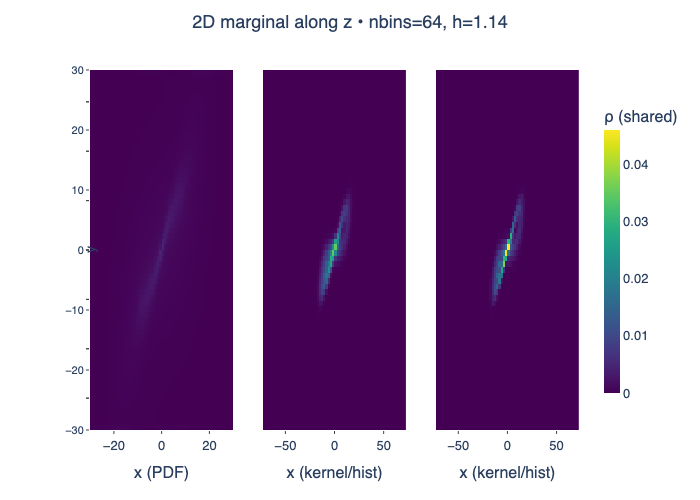

In [6]:
plt = plot_marginal_compare(sol_basic, base_params; nbins=64, axis=:z)
display(plt)

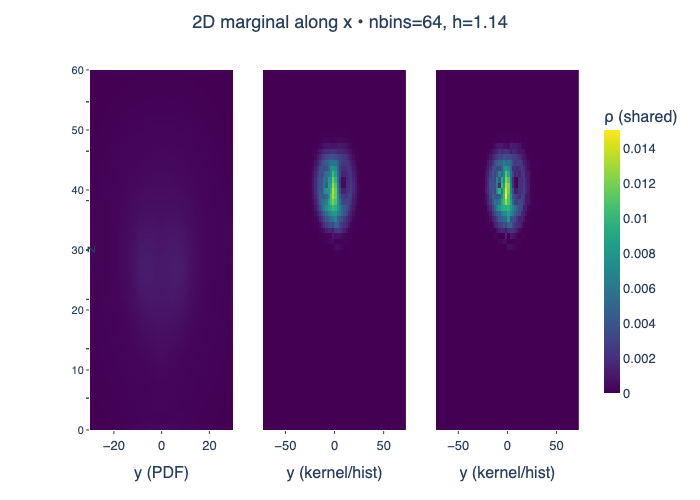

In [7]:
plt = plot_marginal_compare(sol_basic, base_params; nbins=64, axis=:x)
display(plt)

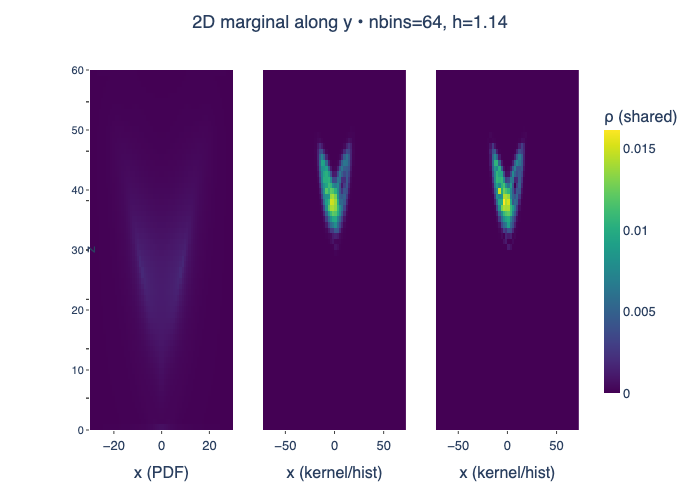

In [8]:
plt = plot_marginal_compare(sol_basic, base_params; nbins=64, axis=:y)
display(plt)

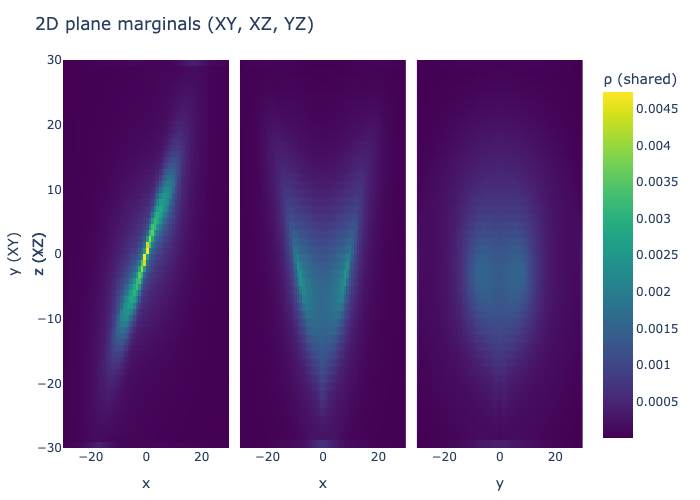

In [11]:
#
xs, ys, zs, rho_pdf = lorenz_pdf_grid_safe(base_params; nx=64, ny=64, nz=48)

# 2D marginals (orient matrices so rows correspond to y / z and cols to x / y as appropriate)
Z_xy = dropdims(sum(rho_pdf, dims=3), dims=3)'   # sum over z -> rows=y, cols=x
XZ   = dropdims(sum(rho_pdf, dims=2), dims=2)'   # sum over y -> rows=z, cols=x
YZ   = dropdims(sum(rho_pdf, dims=1), dims=1)'   # sum over x -> rows=z, cols=y

# shared color limits
zmin = minimum((minimum(Z_xy), minimum(XZ), minimum(YZ)))
zmax = maximum((maximum(Z_xy), maximum(XZ), maximum(YZ)))

trace_xy = PlotlyJS.heatmap(x=xs, y=ys, z=Z_xy, colorscale="Viridis",
    zmin=zmin, zmax=zmax, zauto=false,
    colorbar=attr(title="ρ (shared)"), name="XY")

trace_xz = PlotlyJS.heatmap(x=xs, y=zs, z=XZ, colorscale="Viridis",
    zmin=zmin, zmax=zmax, zauto=false,
    xaxis="x2", yaxis="y2", showscale=false, name="XZ")

trace_yz = PlotlyJS.heatmap(x=ys, y=zs, z=YZ, colorscale="Viridis",
    zmin=zmin, zmax=zmax, zauto=false,
    xaxis="x3", yaxis="y3", showscale=false, name="YZ")

layout = Layout(
    title = "2D plane marginals (XY, XZ, YZ)",
    width = 1200, height = 420,
    xaxis  = attr(domain = [0.00, 0.32], title = "x"),
    yaxis  = attr(domain = [0.00, 1.00], title = "y (XY)"),
    xaxis2 = attr(domain = [0.34, 0.66], title = "x"),
    yaxis2 = attr(domain = [0.00, 1.00], showticklabels=false, title = "z (XZ)"),
    xaxis3 = attr(domain = [0.68, 1.00], title = "y"),
    yaxis3 = attr(domain = [0.00, 1.00], showticklabels=false, title = "z (YZ)"),
    showlegend = false
)

plt = PlotlyJS.plot([trace_xy, trace_xz, trace_yz], layout)
display(plt)